In [16]:
import os, json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path


In [17]:
# Paramètres à modifier
CASE_ID = "la_007"   
AXIS    = "axial"    # "axial" | "coronal" | "sagittal"


ROOT     = Path(os.getcwd()).resolve().parent
DATA_DIR = ROOT / "data" / "Task02_Heart"
PRED_DIR = (
    ROOT / "result" / "nnUnet_results" / "Dataset002_Heart"
    / "nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres"
    / "crossval_results_folds_0_1_2_3_4" / "postprocessed"
)

# cherche le format nnU-Net, sinon le nom original
img_path = DATA_DIR / "imagesTr" / f"{CASE_ID}_0000.nii.gz"
if not img_path.exists():
    img_path = DATA_DIR / "imagesTr" / f"{CASE_ID}.nii.gz"

gt_path   = DATA_DIR / "labelsTr" / f"{CASE_ID}.nii.gz"
pred_path = PRED_DIR  / f"{CASE_ID}.nii.gz"

# Chargement des volumes
img_nib  = nib.load(img_path)
img      = img_nib.get_fdata()
gt       = nib.load(gt_path).get_fdata().astype(np.uint8)
pred     = nib.load(pred_path).get_fdata().astype(np.uint8)
spacing  = img_nib.header.get_zooms()[:3]   # (sx, sy, sz) en mm

# Dice depuis summary.json
with open(PRED_DIR / "summary.json") as f:
    summary = json.load(f)
dice = next(
    c["metrics"]["1"]["Dice"]
    for c in summary["metric_per_case"]
    if Path(c["prediction_file"]).name == f"{CASE_ID}.nii.gz"
)

print(f"Cas : {CASE_ID}  |  Shape : {img.shape}  |  Dice : {dice:.4f}")

Cas : la_007  |  Shape : (320, 320, 130)  |  Dice : 0.9289


## Vue 2D 
Nuage de points 3D (Plotly) 
Rouge - faux positifs
Vert - Correct 
Bleu - faux négatifs

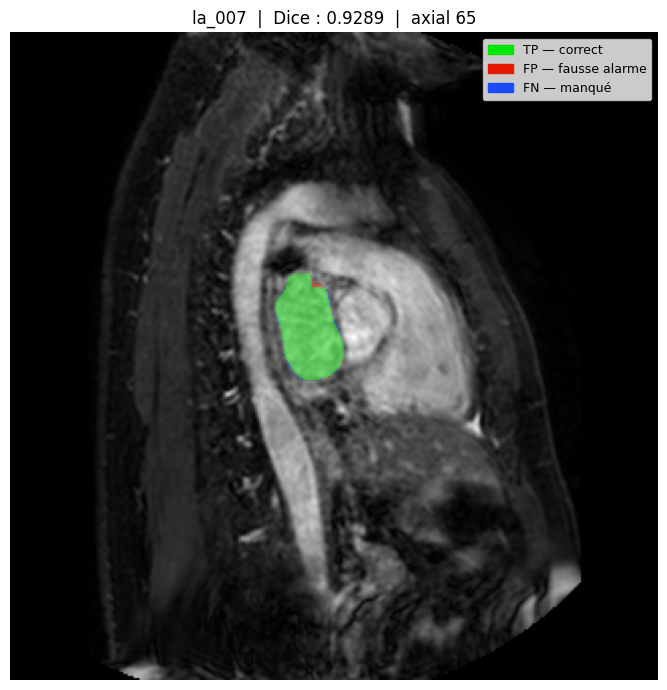

interactive(children=(IntSlider(value=65, continuous_update=False, description='Slice:', layout=Layout(width='…

Espacement voxel   : (1.25, 1.25, 1.37) mm


In [18]:
# Masques d'erreur calculés une seule fois
TP_mask = (pred == 1) & (gt == 1)
FP_mask = (pred == 1) & (gt == 0)
FN_mask = (pred == 0) & (gt == 1)

ALPHA = 0.45   # transparence de l'overlay

def get_slice(vol, i):
    """Extrait et transpose une coupe 2D selon l'axe choisi."""
    if AXIS == "axial":    return vol[:, :, i].T
    if AXIS == "coronal":  return vol[:, i, :].T
    if AXIS == "sagittal": return vol[i, :, :].T

def show_overlay(idx):
    mri  = get_slice(img, idx).astype(float)
    mri  = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)   # normalisation [0,1]
    H, W = mri.shape

    # Couche couleur RGBA : vert=TP, rouge=FP, bleu=FN
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    overlay[get_slice(TP_mask, idx)] = [0.0, 0.9, 0.0, ALPHA]
    overlay[get_slice(FP_mask, idx)] = [0.9, 0.1, 0.0, ALPHA]
    overlay[get_slice(FN_mask, idx)] = [0.1, 0.3, 1.0, ALPHA]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(mri, cmap="gray", origin="lower")
    ax.imshow(overlay, origin="lower")
    ax.legend(
        handles=[
            mpatches.Patch(color=(0.0, 0.9, 0.0), label="TP — correct"),
            mpatches.Patch(color=(0.9, 0.1, 0.0), label="FP — fausse alarme"),
            mpatches.Patch(color=(0.1, 0.3, 1.0), label="FN — manqué"),
        ],
        loc="upper right", fontsize=9,
    )
    ax.set_title(f"{CASE_ID}  |  Dice : {dice:.4f}  |  {AXIS} {idx}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

N = {"axial": img.shape[2], "coronal": img.shape[1], "sagittal": img.shape[0]}[AXIS]
widgets.interact(
    show_overlay,
    idx=widgets.IntSlider(value=N // 2, min=0, max=N - 1,
                          description="Slice:", continuous_update=False,
                          layout=widgets.Layout(width="520px")),
);


print(f"Espacement voxel   : {tuple(round(float(s), 2) for s in spacing)} mm")

## Vue 3D 
Nuage de points 3D (Plotly) 
Rouge - faux positifs
Vert - Correct 
Bleu - faux négatifs

In [10]:
import importlib, subprocess, sys
if importlib.util.find_spec("plotly") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "plotly"], check=True)

import plotly.graph_objects as go
from IPython.display import HTML

traces = []
for mask, color, label in [
    (TP_mask, "green", "TP"),
    (FP_mask, "red",   "FP"),
    (FN_mask, "blue",  "FN"),
]:
    pts = np.argwhere(mask)
    if len(pts) == 0:
        continue
    traces.append(go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers",
        marker=dict(size=1.5, color=color, opacity=0.5),
        name=label,
    ))

fig = go.Figure(data=traces)
fig.update_layout(
    title=f"Vue 3D — {CASE_ID}  |  Dice : {dice:.4f}",
    scene=dict(aspectmode="data", xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
    height=700,
)
display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))